TE, V=1, p=0: xi = 0.739085
TM, V=1, p=0: xi = 0.743125
TE, V=10, p=0: xi = 0.142755
TE, V=10, p=1: xi = 0.285234
TE, V=10, p=2: xi = 0.427110
TE, V=10, p=3: xi = 0.567921
TE, V=10, p=4: xi = 0.706889
TE, V=10, p=5: xi = 0.842320
TE, V=10, p=6: xi = 0.967888
TM, V=10, p=0: xi = 0.143012
TM, V=10, p=1: xi = 0.285731
TM, V=10, p=2: xi = 0.427808
TM, V=10, p=3: xi = 0.568760
TM, V=10, p=4: xi = 0.707774
TM, V=10, p=5: xi = 0.843096
TM, V=10, p=6: xi = 0.968241


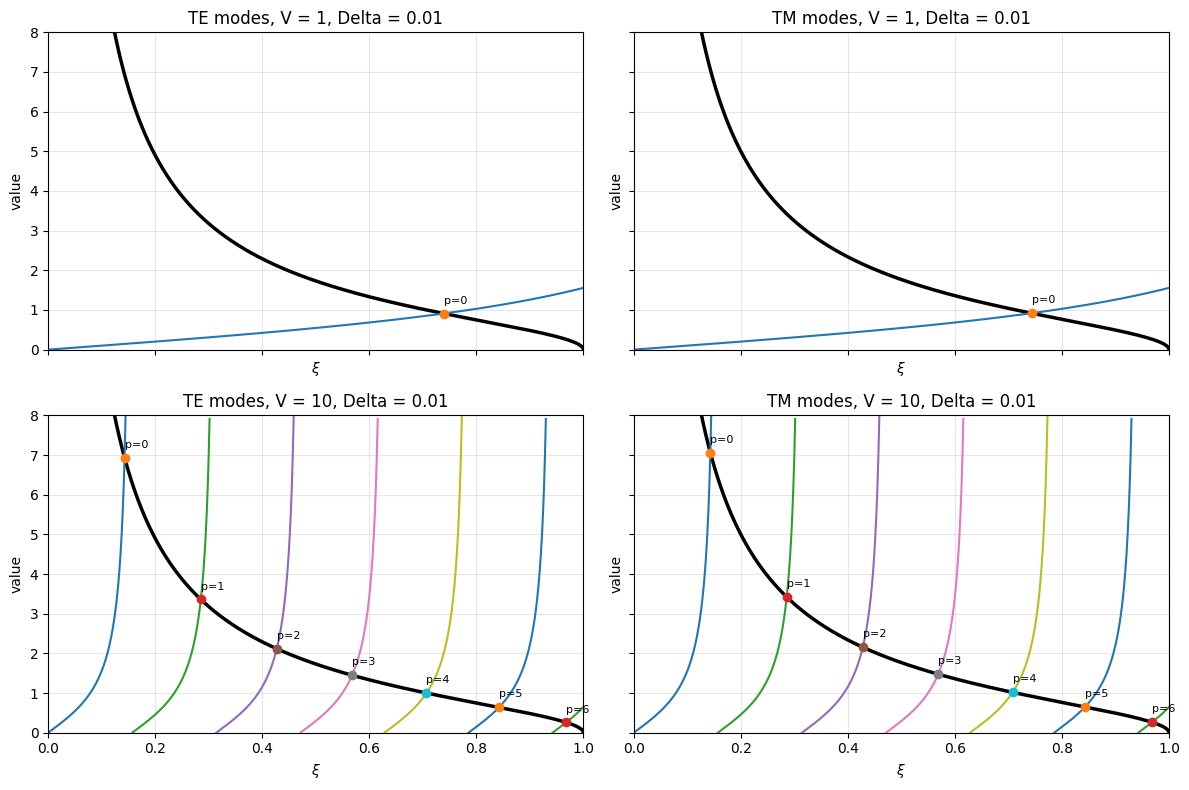

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Plot equation (8.123):
#
# tan(V xi - p pi/2) = f sqrt(1/xi^2 - 1)
#
# TE: f = 1
# TM: f = 1 / (1 - 2 Delta)
# ============================================================

# If the problem gives n1 and n2, use:
# n1 = ...
# n2 = ...
# Delta = (n1**2 - n2**2) / (2 * n1**2)

Delta = 0.01       # change this if needed
Vs = [1, 10]
pols = ["TE", "TM"]

xi = np.linspace(1e-4, 0.9999, 6000)
ymax = 8


def f_factor(pol, Delta):
    if pol == "TE":
        return 1.0
    elif pol == "TM":
        return 1.0 / (1.0 - 2.0 * Delta)
    else:
        raise ValueError("pol must be 'TE' or 'TM'")


def rhs(xi, pol, Delta):
    """Right-hand side of Eq. 8.123."""
    f = f_factor(pol, Delta)
    return f * np.sqrt(1.0 / xi**2 - 1.0)


def lhs(xi, V, p):
    """Left-hand side of Eq. 8.123."""
    return np.tan(V * xi - p * np.pi / 2.0)


def allowed_p_values(V):
    """
    p is allowed if the beginning of its branch lies below xi = 1:
        p*pi/(2V) < 1
    """
    ps = []
    p = 0
    while p * np.pi / (2 * V) < 1:
        ps.append(p)
        p += 1
    return ps


def phase_equation(xi, V, p, pol, Delta):
    """
    Equivalent root equation without tangent singularities:

        V xi - p*pi/2 = arctan(f sqrt(1/xi^2 - 1))
    """
    f = f_factor(pol, Delta)
    return V * xi - p * np.pi / 2.0 - np.arctan(f * np.sqrt(1.0 / xi**2 - 1.0))


def find_root_bisection(V, p, pol, Delta, tol=1e-12, max_iter=100):
    """
    Finds one root on the p-th physical branch.
    """
    left = p * np.pi / (2 * V)
    right = (p + 1) * np.pi / (2 * V)

    lo = max(left + 1e-10, 1e-10)
    hi = min(right - 1e-10, 1.0 - 1e-10)

    if lo >= hi:
        return None

    flo = phase_equation(lo, V, p, pol, Delta)
    fhi = phase_equation(hi, V, p, pol, Delta)

    if flo * fhi > 0:
        return None

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        fmid = phase_equation(mid, V, p, pol, Delta)

        if abs(fmid) < tol:
            return mid

        if flo * fmid < 0:
            hi = mid
            fhi = fmid
        else:
            lo = mid
            flo = fmid

    return 0.5 * (lo + hi)


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for i, V in enumerate(Vs):
    for j, pol in enumerate(pols):
        ax = axes[i, j]

        # Plot RHS
        y_rhs = rhs(xi, pol, Delta)
        ax.plot(xi, y_rhs, "k", linewidth=2.5, label="RHS")

        # Plot LHS branch by branch
        for p in allowed_p_values(V):
            left = p * np.pi / (2 * V)
            right = (p + 1) * np.pi / (2 * V)

            branch_mask = (xi > left) & (xi < right) & (xi < 1)
            xi_branch = xi[branch_mask]

            if len(xi_branch) == 0:
                continue

            y_lhs = lhs(xi_branch, V, p)

            # Hide huge values near tangent asymptotes
            y_lhs = np.where((y_lhs >= 0) & (y_lhs < ymax), y_lhs, np.nan)

            ax.plot(xi_branch, y_lhs, linewidth=1.5, label=f"LHS p={p}")

            # Find and mark intersection
            root = find_root_bisection(V, p, pol, Delta)
            if root is not None:
                y_root = rhs(root, pol, Delta)
                if y_root < ymax:
                    ax.plot(root, y_root, "o")
                    ax.text(root, y_root + 0.25, f"p={p}", fontsize=8)

                print(f"{pol}, V={V}, p={p}: xi = {root:.6f}")

        ax.set_title(f"{pol} modes, V = {V}, Delta = {Delta}")
        ax.set_xlabel(r"$\xi$")
        ax.set_ylabel("value")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, ymax)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()